In [ ]:

import torch  
import torch.nn as nn  
import torch.optim as optim  
import torchvision  
import torchvision.transforms as transforms  h
import matplotlib.pyplot as plt 
import numpy as np 

# Thiết lập device (GPU nếu có, không thì CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sử dụng: {device}")

# Tải dữ liệu MNIST (chuyển ảnh thành tensor và chuẩn hóa)
# Normalize: (x - 0.5) / 0.5 để đưa giá trị pixel về [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),  # Chuyển ảnh PIL thành tensor PyTorch
    transforms.Normalize((0.5,), (0.5,))  # Chuẩn hóa: mean=0.5, std=0.5
])

print("Đang tải dữ liệu MNIST...")
# Tải tập huấn luyện (60,000 ảnh)
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# Tải tập kiểm tra (10,000 ảnh)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Tạo DataLoader để lấy batch dữ liệu
# batch_size=64: mỗi lần lấy 64 ảnh
# shuffle=True: xáo trộn dữ liệu khi huấn luyện (để tránh overfitting)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
# Không cần xáo trộn tập test (chỉ đánh giá mô hình)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

# Định nghĩa hàm tính loss (Cross Entropy cho phân loại)
criterion = nn.CrossEntropyLoss()
print("Xong! Sẵn sàng training...")

Sử dụng: cpu
Đang tải dữ liệu MNIST...
Xong! Sẵn sàng training...



## Yêu cầu
Dựa trên đoạn code CNN đã cung cấp (phân loại MNIST), hãy thực hiện các nhiệm vụ sau. Gửi lại code hoàn chỉnh kèm giải thích ngắn gọn cho từng câu hỏi trong file Jupyter Notebook.

  ### Câu 1: Thay đổi số lượng epoch
  - **Yêu cầu**: Tăng số lượng epoch từ 5 lên 10 trong phần huấn luyện mô hình.
  - **Hướng dẫn**: Tìm dòng `for epoch in range(5):` và sửa thành `for epoch in range(10):`. Chạy lại code và ghi nhận:
    - Độ chính xác trên tập test có thay đổi không? Nếu có, tăng hay giảm?
    - Biểu đồ mất mát (loss) thay đổi thế nào qua 10 epoch? Có xu hướng nào đáng chú ý không (ví dụ: giảm đều, chững lại)?
  -  Giải thích về lý do tại sao số epoch ảnh hưởng đến kết quả.

### Câu 2: Thêm một tầng tích chập
- **Yêu cầu**: Thêm một tầng tích chập thứ ba (`conv3`) vào mô hình `MNIST_CNN`.
- **Hướng dẫn**:
  - Trong hàm `__init__`, thêm `self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)` (32 kênh đầu vào từ `conv2`, 64 kênh đầu ra).
  - Trong hàm `forward`, thêm `x = self.pool(torch.relu(self.conv3(x)))` sau dòng `x = self.pool(torch.relu(self.conv2(x)))`.
  - Kích thước sau `conv3` và pooling sẽ là 64x1x1 (vì 5x5 -> 3x3 -> 1x1 sau hai lần pooling và tích chập). Sửa tầng `fc1` thành `self.fc1 = nn.Linear(64 * 1 * 1, 10)` và dòng `x.view(-1, 64 * 1 * 1)` tương ứng.
  - Chạy lại code và ghi nhận độ chính xác mới trên tập test.
- Viết ngắn gọn về tác dụng của việc thêm tầng tích chập (ví dụ: tìm đặc trưng phức tạp hơn, ảnh hưởng đến độ chính xác).

### Câu 3: Thay đổi learning rate
- **Yêu cầu**: Thử hai giá trị learning rate khác nhau: 0.001 và 0.1 (thay vì 0.01 ban đầu).
- **Hướng dẫn**: Tìm dòng `optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)` và thay `lr=0.001` rồi `lr=0.1`. Chạy lại code với từng giá trị và ghi nhận:
  - Độ chính xác trên tập test với mỗi learning rate.
  - Biểu đồ mất mát thay đổi ra sao? (Ví dụ: dao động mạnh, giảm chậm, hoặc không hội tụ).
- Cách learning rate ảnh hưởng đến quá trình học của mô hình như thế nào?

### Câu 4: Vẽ thêm feature map từ tầng tích chập thứ hai
- **Yêu cầu**: Sửa hàm `visualize_feature_map` để vẽ thêm hai feature map từ tầng `conv2`.
- **Hướng dẫn**:
  - Trong hàm `visualize_feature_map`, thêm dòng `conv2_output = torch.relu(self.conv2(self.pool(torch.relu(self.conv1(img)))))` để tính feature map từ `conv2`.
  - Tăng khung hình từ 3 cột thành 5 cột: `plt.figure(figsize=(20, 4))` và sửa các subplot thành `plt.subplot(1, 5, ...)`.
  - Thêm hai subplot để vẽ `conv2_output[0, 0]` và `conv2_output[0, 1]` (tương tự như `conv1_output`).
  - Chạy lại và mô tả sự khác biệt giữa feature map từ `conv1` và `conv2` (ví dụ: chi tiết hơn, trừu tượng hơn).
- Viết ngắn gọn về sự khác biệt giữa feature map từ các tầng khác nhau.

## Nộp bài
- Nộp file Jupyter Notebook (.ipynb) lên github.
- Mỗi câu cần có:
  - Code đã sửa đổi.
  - Kết quả chạy (độ chính xác, biểu đồ loss, hình feature map nếu có).
  - Sinh viên phải sử dụng Markdown cell trong Jupyter Notebook để viết phần giải thích

## Gợi ý
- Đọc lại lý thuyết CNN (tích chập, ReLU, pooling, fully connected) để hiểu tác động của từng thay đổi.
- Chạy code từng phần để kiểm tra lỗi (ví dụ: kiểm tra kích thước tensor sau khi thêm `conv3`).

## Deadline
- 23h59p ngày 11/03/2026.



## Câu 1: Tăng Epoch từ 5 lên 10

### Giải thích:
- **Epoch**: Một vòng lặp đầy đủ qua toàn bộ tập huấn luyện
- **Tăng epoch**: Mô hình có nhiều cơ hội để tối ưu hóa trọng số
- **Kỳ vọng**: Độ chính xác tăng, loss giảm (nhưng có giới hạn - overfitting)

In [ ]:
# --- CÂU 1: TRAINING VỚI 10 EPOCHS ---
print("\n" + "="*50)
print("CÂU 1: TRAINING VỚI 10 EPOCHS")
print("="*50)

# Định nghĩa mô hình CNN với 2 tầng tích chập
class MNIST_CNN_Q1(nn.Module):
    def __init__(self):
        super(MNIST_CNN_Q1, self).__init__()
        # Tầng Conv1: 1 channel đầu vào (ảnh xám) -> 16 channels
        # kernel_size=3: lọc 3x3, stride=1: bước dịch 1 pixel, padding=1: thêm viền để giữ kích thước
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        # Max Pooling: giảm kích thước ảnh từ 28x28 -> 14x14 (kernel=2, stride=2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Tầng Conv2: 16 channels đầu vào -> 32 channels
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        # Fully Connected: 32 * 7 * 7 = 1568 đầu vào -> 10 đầu ra (10 lớp: 0-9)
        self.fc1 = nn.Linear(32 * 7 * 7, 10)  # 28/2/2 = 7

    def forward(self, x):
        # Conv1 + ReLU + Pooling: 28x28 -> 14x14
        x = self.pool(torch.relu(self.conv1(x)))
        # Conv2 + ReLU + Pooling: 14x14 -> 7x7
        x = self.pool(torch.relu(self.conv2(x)))
        # Chuyển 3D tensor thành 1D vector để đưa vào Fully Connected
        x = x.view(-1, 32 * 7 * 7)
        # Fully Connected layer (không có activation, chỉ là logits)
        return self.fc1(x)

# Khởi tạo mô hình và chuyển lên device (GPU hoặc CPU)
model_q1 = MNIST_CNN_Q1().to(device)
#cập nhật trọng số bằng gradient descent
# lr=0.01: learning rate, momentum=0.9: tăng tốc độ hội tụ
optimizer_q1 = optim.SGD(model_q1.parameters(), lr=0.01, momentum=0.9)

# Hàm tính loss (đã định nghĩa ở trên)
criterion = nn.CrossEntropyLoss()

# Training với 10 epochs (Câu 1: tăng từ 5 lên 10)
epochs_q1 = 10
loss_history_q1 = []  # Lưu loss sau mỗi epoch

# Vòng lặp epochs
for epoch in range(epochs_q1):
    running_loss = 0.0  # Tích lũy loss trong một epoch
    
    # Vòng lặp qua từng batch dữ liệu
    for images, labels in train_loader:
        # Chuyển dữ liệu lên device
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass: đưa ảnh vào mô hình
        optimizer_q1.zero_grad()  # Xóa gradient từ epoch trước
        outputs = model_q1(images)  # Dự đoán của mô hình
        loss = criterion(outputs, labels)  # Tính loss (sai lệch so với nhãn thực)
        
        # Backward pass: tính gradient
        loss.backward()
        # Update trọng số theo gradient
        optimizer_q1.step()
        
        # Tích lũy loss
        running_loss += loss.item()
    
    # Tính loss trung bình cho epoch
    avg_loss = running_loss / len(train_loader)
    loss_history_q1.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs_q1} - Loss: {avg_loss:.4f}")

# Đánh giá mô hình trên tập test
model_q1.eval()  # Chuyển sang chế độ evaluation (tắt Dropout, BatchNorm, ...)
correct = 0  # Đếm số dự đoán đúng
total = 0  # Tổng số mẫu test

with torch.no_grad():  # Không tính gradient (tốc độ nhanh hơn)
    # Duyệt qua từng batch test
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        # Dự đoán
        outputs = model_q1(images)
        # Lấy lớp có xác suất cao nhất
        _, predicted = torch.max(outputs.data, 1)
        # Đếm số dự đoán đúng
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Tính độ chính xác (%)
accuracy_q1 = 100 * correct / total
print(f"\nĐộ chính xác trên test set (10 epochs): {accuracy_q1:.2f}%")


CÂU 1: TRAINING VỚI 10 EPOCHS
Epoch 1/10 - Loss: 0.2092
Epoch 2/10 - Loss: 0.0639
Epoch 3/10 - Loss: 0.0486
Epoch 4/10 - Loss: 0.0402
Epoch 5/10 - Loss: 0.0340
Epoch 6/10 - Loss: 0.0301
Epoch 7/10 - Loss: 0.0258
Epoch 8/10 - Loss: 0.0236
Epoch 9/10 - Loss: 0.0207
Epoch 10/10 - Loss: 0.0198

Độ chính xác trên test set (10 epochs): 98.85%


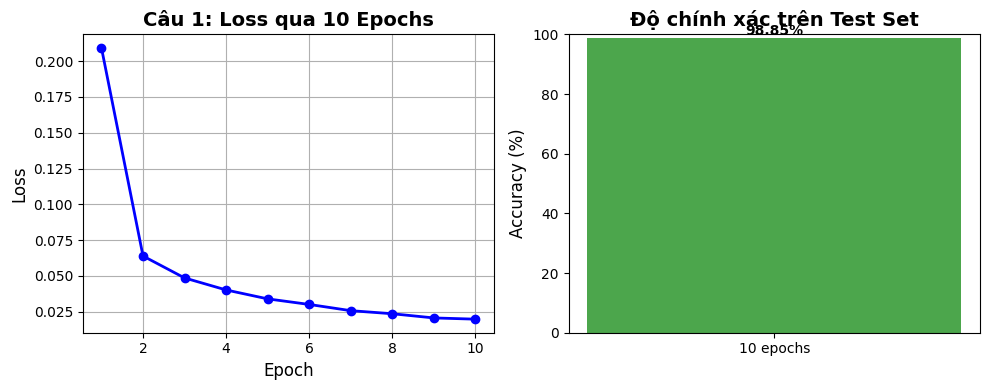

In [ ]:
# Vẽ biểu đồ Loss và Accuracy cho câu 1
plt.figure(figsize=(10, 4))  # Tạo hình với kích thước 10x4

# Subplot 1: Biểu đồ Loss theo epochs
plt.subplot(1, 2, 1)  # 1 hàng, 2 cột, vị trí 1
# Vẽ đường loss với marker 'o' (tròn)
plt.plot(range(1, epochs_q1+1), loss_history_q1, 'b-o', linewidth=2)
plt.xlabel('Epoch', fontsize=12)  # Nhãn trục x
plt.ylabel('Loss', fontsize=12)  # Nhãn trục y
plt.title('Câu 1: Loss qua 10 Epochs', fontsize=14, fontweight='bold')
plt.grid(True)  # Hiển thị lưới

# Subplot 2: Biểu đồ cột Accuracy
plt.subplot(1, 2, 2)  # 1 hàng, 2 cột, vị trí 2
# Tạo biểu đồ cột với màu xanh lá
plt.bar([f"10 epochs"], [accuracy_q1], color='green', alpha=0.7)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Độ chính xác trên Test Set', fontsize=14, fontweight='bold')
plt.ylim([0, 100])  # Giới hạn trục y từ 0-100%

# Thêm giá trị chính xác trên cột
for i, v in enumerate([accuracy_q1]):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')

# Điều chỉnh khoảng cách giữa các subplot
plt.tight_layout()
# Hiển thị biểu đồ
plt.show()

# PHẦN TRẢ LỜI CÂU 2: THÊM TẦNG TÍCH CHẬP THỨ BA


## Câu 2: Thêm Conv3

### Giải thích:
- **Conv layer**: Trích xuất các đặc trưng từ ảnh
- **Thêm Conv3**: Mô hình học được các đặc trưng phức tạp hơn (cạnh → hình dạng → đối tượng)
- **Tính toán kích thước**:
  - Input: 28×28
  - Sau Conv1 + Pool: 14×14 × 16 channels
  - Sau Conv2 + Pool: 7×7 × 32 channels
  - Sau Conv3 (kernel=3, padding=0): 5×5 × 64 channels
  - Sau Pool: 2×2 × 64 channels (không phải 1×1, cần điều chỉnh)

In [ ]:
# --- CÂU 2: TRAINING VỚI CONV3 (3 TẦNG TÍCH CHẬP) ---
print("\n" + "="*50)
print("CÂU 2: TRAINING VỚI CONV3")
print("="*50)

# Định nghĩa mô hình CNN với 3 tầng tích chập (Câu 2)
class MNIST_CNN_Q2(nn.Module):
    def __init__(self):
        super(MNIST_CNN_Q2, self).__init__()
        
        # Tầng 1: Conv1 và Pooling
        # 1 đầu vào -> 16 channels; kernel 3x3; padding=1 giữ kích thước
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        # Max pooling: 28x28 -> 14x14
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Tầng 2: Conv2 và Pooling
        # 16 đầu vào -> 32 channels; kernel 3x3; padding=1 giữ kích thước
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        
        # Tầng 3 (MỚI): Conv3 - thêm tầng tích chập thứ ba
        # 32 đầu vào -> 64 channels; kernel 3x3; padding=0 (không thêm viền)
        # padding=0 sẽ giảm kích thước: 7x7 -> 5x5
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0)
        
        # Fully connected layer
        # Sau Conv3 (7x7 -> 5x5) và Pooling (5x5 -> 2x2): 64 * 2 * 2 = 256
        self.fc1 = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        # Block 1: Conv1 + ReLU + Pooling
        # Input: 1x28x28 -> Output: 16x14x14
        x = self.pool(torch.relu(self.conv1(x)))       # 28 -> 14
        
        # Block 2: Conv2 + ReLU + Pooling
        # Input: 16x14x14 -> Output: 32x7x7
        x = self.pool(torch.relu(self.conv2(x)))       # 14 -> 7
        
        # Block 3 (MỚI): Conv3 + ReLU + Pooling
        # Input: 32x7x7 -> Conv3 (padding=0): 64x5x5 -> Pooling: 64x2x2
        x = self.pool(torch.relu(self.conv3(x)))       # 7 -> 5 -> 2 (sau pool)
        
        # Chuyển thành vector phẳng cho Fully Connected
        x = x.view(-1, 64 * 2 * 2)
        return self.fc1(x)

# Khởi tạo mô hình
model_q2 = MNIST_CNN_Q2().to(device)
# Optimizer SGD với learning rate 0.01
optimizer_q2 = optim.SGD(model_q2.parameters(), lr=0.01, momentum=0.9)

# Training với 10 epochs
epochs_q2 = 10
loss_history_q2 = []

# Vòng lặp epochs
for epoch in range(epochs_q2):
    running_loss = 0.0
    
    # Duyệt từng batch
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer_q2.zero_grad()
        outputs = model_q2(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer_q2.step()
        
        running_loss += loss.item()
    
    # Tính loss trung bình
    avg_loss = running_loss / len(train_loader)
    loss_history_q2.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs_q2} - Loss: {avg_loss:.4f}")

# Đánh giá mô hình trên tập test
model_q2.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_q2(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Tính độ chính xác
accuracy_q2 = 100 * correct / total
print(f"\nĐộ chính xác trên test set (with Conv3): {accuracy_q2:.2f}%")


CÂU 2: TRAINING VỚI CONV3
Epoch 1/10 - Loss: 0.2918
Epoch 2/10 - Loss: 0.0610
Epoch 3/10 - Loss: 0.0412
Epoch 4/10 - Loss: 0.0341
Epoch 5/10 - Loss: 0.0283
Epoch 6/10 - Loss: 0.0234
Epoch 7/10 - Loss: 0.0204
Epoch 8/10 - Loss: 0.0177
Epoch 9/10 - Loss: 0.0143
Epoch 10/10 - Loss: 0.0127

Độ chính xác trên test set (with Conv3): 99.24%


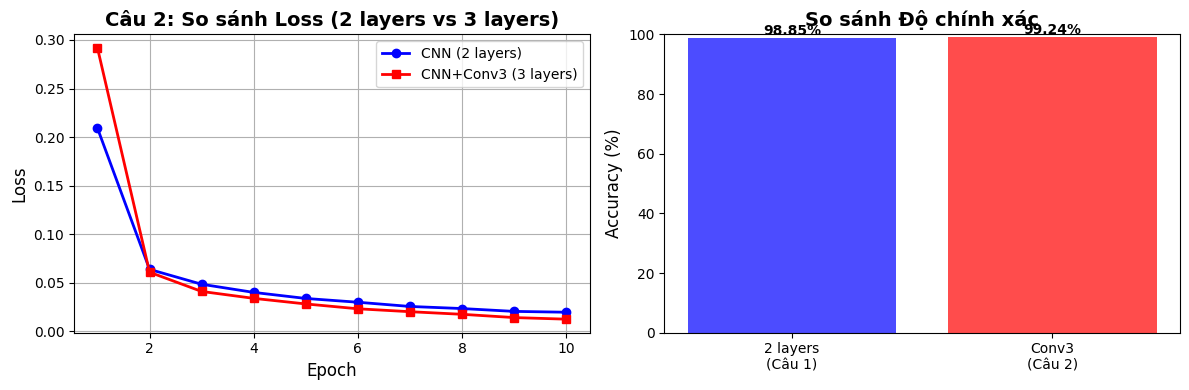


So sánh Câu 1 vs Câu 2:
  - 2 layers (Câu 1): 98.85%
  - Conv3 (Câu 2): 99.24%
  - Chênh lệch: +0.39%


In [ ]:
# Vẽ biểu đồ so sánh câu 1 (2 layers) vs câu 2 (3 layers)
plt.figure(figsize=(12, 4))

# Subplot 1: So sánh Loss
plt.subplot(1, 2, 1)
# Vẽ loss của mô hình 2 layers (có marker 'o')
plt.plot(range(1, epochs_q1+1), loss_history_q1, 'b-o', label='CNN (2 layers)', linewidth=2)
# Vẽ loss của mô hình 3 layers (có marker 's')
plt.plot(range(1, epochs_q2+1), loss_history_q2, 'r-s', label='CNN+Conv3 (3 layers)', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Câu 2: So sánh Loss (2 layers vs 3 layers)', fontsize=14, fontweight='bold')
plt.legend()  # Hiển thị chú thích
plt.grid(True)

# Subplot 2: So sánh Accuracy
plt.subplot(1, 2, 2)
# Tên các mô hình
models = ['2 layers\n(Câu 1)', 'Conv3\n(Câu 2)']
# Độ chính xác tương ứng
accuracies = [accuracy_q1, accuracy_q2]
# Màu sắc cho từng cột
colors = ['blue', 'red']
# Vẽ biểu đồ cột
bars = plt.bar(models, accuracies, color=colors, alpha=0.7)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('So sánh Độ chính xác', fontsize=14, fontweight='bold')
plt.ylim([0, 100])

# Thêm giá trị chính xác trên mỗi cột
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# In ra bảng so sánh
print(f"\nSo sánh Câu 1 vs Câu 2:")
print(f"  - 2 layers (Câu 1): {accuracy_q1:.2f}%")
print(f"  - Conv3 (Câu 2): {accuracy_q2:.2f}%")
print(f"  - Chênh lệch: {accuracy_q2 - accuracy_q1:+.2f}%")


# PHẦN TRẢ LỜI CÂU 3: THAY ĐỔI LEARNING RATE


## Câu 3: Thử Learning Rate 0.001 và 0.1

### Giải thích:
- **Learning Rate (LR)**: Độ lớn của bước cập nhật trọng số
- **LR quá nhỏ (0.001)**: Huấn luyện chậm, có thể bị kẹt ở cực trị địa phương
- **LR quá lớn (0.1)**: Huấn luyện nhanh nhưng có thể dao động, không hội tụ
- **LR hợp lý (0.01)**: Cân bằng giữa tốc độ học và sự ổn định

In [ ]:
# --- CÂU 3: TRAINING VỚI LEARNING RATES KHÁC NHAU ---
print("\n" + "="*50)
print("CÂU 3: SO SÁNH LEARNING RATES")
print("="*50)

# Hàm tạo mô hình CNN cơ bản (2 layers)
def create_model():
    class MNIST_CNN_Q3(nn.Module):
        def __init__(self):
            super(MNIST_CNN_Q3, self).__init__()
            # Conv1: 1 -> 16 channels
            self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
            # Max pooling
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
            # Conv2: 16 -> 32 channels
            self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
            # Fully connected: 32*7*7 -> 10
            self.fc1 = nn.Linear(32 * 7 * 7, 10)

        def forward(self, x):
            # Conv1 + ReLU + Pool: 28*28 -> 14*14
            x = self.pool(torch.relu(self.conv1(x)))
            # Conv2 + ReLU + Pool: 14*14 -> 7*7
            x = self.pool(torch.relu(self.conv2(x)))
            # Flatten
            x = x.view(-1, 32 * 7 * 7)
            return self.fc1(x)
    
    return MNIST_CNN_Q3().to(device)

# Các learning rates để thử: 0.001 (quá nhỏ) và 0.1 (quá lớn)
learning_rates = [0.001, 0.1]
# Lưu kết quả
results_q3 = {}
loss_histories_q3 = {}  # Lưu loss history cho từng LR
accuracies_q3 = {}  # Lưu accuracy cho từng LR

# Duyệt qua từng learning rate
for lr in learning_rates:
    print(f"\n--- Training với LR = {lr} ---")
    
    # Khởi tạo mô hình mới
    model_q3 = create_model()
    # Optimizer SGD với learning rate hiện tại
    optimizer_q3 = optim.SGD(model_q3.parameters(), lr=lr, momentum=0.9)
    
    # Training
    epochs_q3 = 10
    loss_history = []
    
    # Vòng lặp epochs
    for epoch in range(epochs_q3):
        running_loss = 0.0
        
        # Duyệt từng batch
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            optimizer_q3.zero_grad()
            outputs = model_q3(images)
            loss = criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            optimizer_q3.step()
            
            running_loss += loss.item()
        
        # Tính loss trung bình
        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"  Epoch {epoch+1}/{epochs_q3} - Loss: {avg_loss:.4f}")
    
    # Lưu loss history
    loss_histories_q3[lr] = loss_history
    
    # Đánh giá trên test set
    model_q3.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        # Duyệt từng batch test
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_q3(images)
            # Lấy dự đoán
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # Tính độ chính xác
    accuracy = 100 * correct / total
    accuracies_q3[lr] = accuracy
    print(f"  Độ chính xác: {accuracy:.2f}%")


CÂU 3: SO SÁNH LEARNING RATES

--- Training với LR = 0.001 ---
  Epoch 1/10 - Loss: 0.6947
  Epoch 2/10 - Loss: 0.1936
  Epoch 3/10 - Loss: 0.1325
  Epoch 4/10 - Loss: 0.1043
  Epoch 5/10 - Loss: 0.0889
  Epoch 6/10 - Loss: 0.0790
  Epoch 7/10 - Loss: 0.0719
  Epoch 8/10 - Loss: 0.0664
  Epoch 9/10 - Loss: 0.0619
  Epoch 10/10 - Loss: 0.0586
  Độ chính xác: 98.20%

--- Training với LR = 0.1 ---
  Epoch 1/10 - Loss: 0.1300
  Epoch 2/10 - Loss: 0.0559
  Epoch 3/10 - Loss: 0.0476
  Epoch 4/10 - Loss: 0.0395
  Epoch 5/10 - Loss: 0.0381
  Epoch 6/10 - Loss: 0.0332
  Epoch 7/10 - Loss: 0.0341
  Epoch 8/10 - Loss: 0.0305
  Epoch 9/10 - Loss: 0.0350
  Epoch 10/10 - Loss: 0.0348
  Độ chính xác: 98.56%


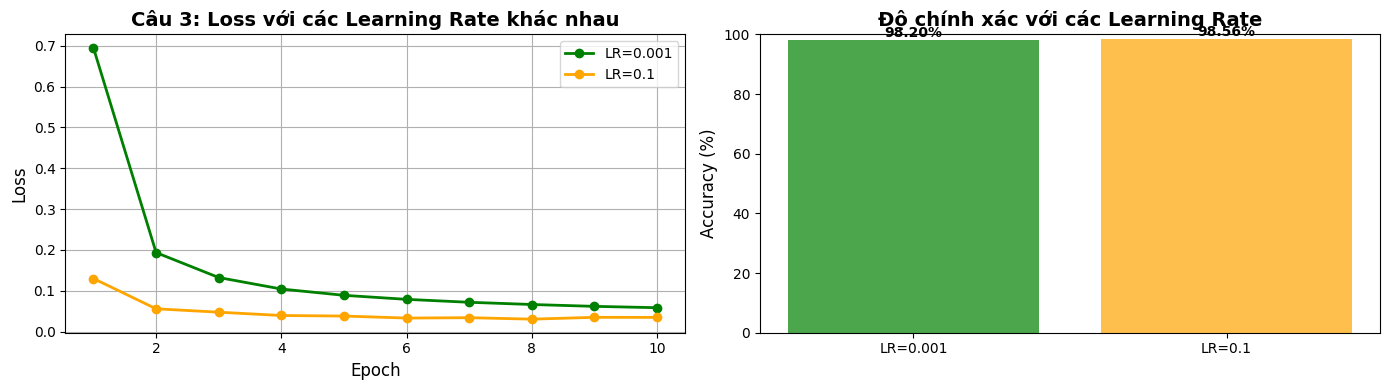


TÓM TẮT CÂU 3:
LR = 0.001: Accuracy = 98.20%
LR = 0.1: Accuracy = 98.56%


In [ ]:
# Vẽ biểu đồ so sánh Learning Rates
plt.figure(figsize=(14, 4))

# Subplot 1: So sánh Loss
plt.subplot(1, 2, 1)
# Màu sắc cho từng LR
colors_lr = ['green', 'orange']
# Vẽ loss cho từng learning rate
for lr, color in zip(learning_rates, colors_lr):
    plt.plot(range(1, 11), loss_histories_q3[lr], 'o-', label=f'LR={lr}', linewidth=2, color=color)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Câu 3: Loss với các Learning Rate khác nhau', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)

# Subplot 2: So sánh Accuracy
plt.subplot(1, 2, 2)
# Tạo biểu đồ cột
bars = plt.bar([f'LR={lr}' for lr in learning_rates], 
               [accuracies_q3[lr] for lr in learning_rates], 
               color=colors_lr, alpha=0.7)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Độ chính xác với các Learning Rate', fontsize=14, fontweight='bold')
plt.ylim([0, 100])

# Thêm giá trị chính xác lên cột
for i, (lr, bar) in enumerate(zip(learning_rates, bars)):
    acc = accuracies_q3[lr]
    plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# In ra bảng tóm tắt
print("\n" + "="*50)
print("TÓM TẮT CÂU 3:")
print("="*50)
for lr in learning_rates:
    print(f"LR = {lr}: Accuracy = {accuracies_q3[lr]:.2f}%")


# PHẦN TRẢ LỜI CÂU 4: VẼ FEATURE MAP TỪ CONV2


## Câu 4: Hình dung Feature Maps

### Giải thích:
- **Feature Map**: Kết quả đầu ra của tầng tích chập
- **Conv1**: Nhận diện các đặc trưng cơ sở (cạnh, góc, kết cấu)
- **Conv2**: Nhận diện các đặc trưng cao hơn (hình dạng, mẫu)
- **Sự khác biệt**: Feature map từ Conv2 thường trừu tượng hơn, có thông tin chi tiết hơn


CÂU 4: HÌNH DỰA FEATURE MAP
Hình dạng các feature maps:
  Conv1 output: torch.Size([1, 16, 28, 28])
  Pool1 output: torch.Size([1, 16, 14, 14])
  Conv2 output: torch.Size([1, 32, 14, 14])
  Pool2 output: torch.Size([1, 32, 7, 7])


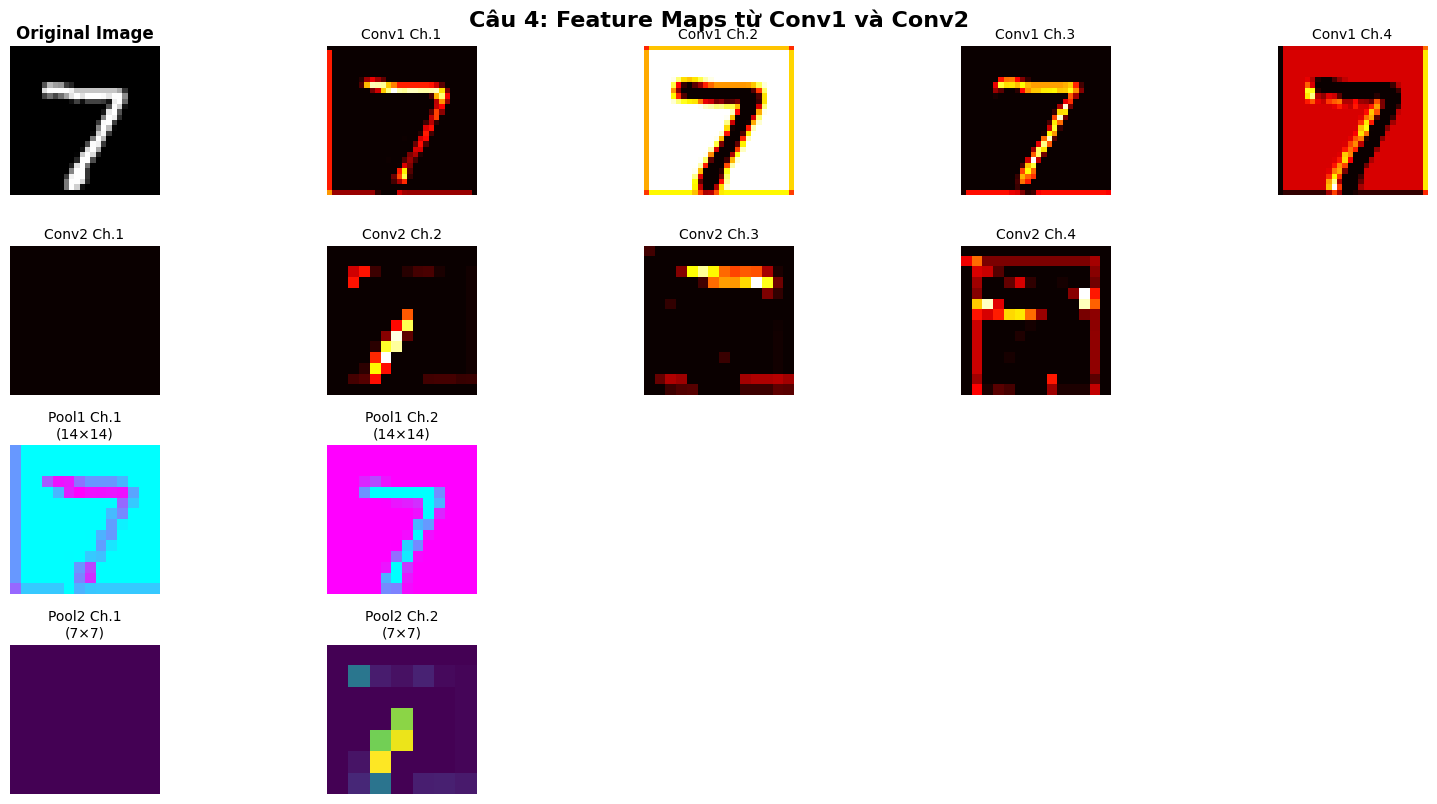


Giải thích Feature Maps:
  - Conv1: Nhận diện cạnh, góc, kết cấu cơ bản
  - Conv2: Nhận diện hình dạng phức tạp hơn, kết hợp các đặc trưng từ Conv1
  - Pool layers: Giảm kích thước, giữ lại thông tin quan trọng


In [ ]:
# --- CÂU 4: HÌNH DỰA FEATURE MAP TỪ CONV1 VÀ CONV2 ---
print("\n" + "="*50)
print("CÂU 4: HÌNH DỰA FEATURE MAP")
print("="*50)

# Tạo mô hình có khả năng trích xuất feature maps
class MNIST_CNN_FeatureExtractor(nn.Module):
    def __init__(self):
        super(MNIST_CNN_FeatureExtractor, self).__init__()
        # Conv1: 1 -> 16 channels
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        # Max pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Conv2: 16 -> 32 channels
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        # Fully connected
        self.fc1 = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        # Forward pass bình thường
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        return self.fc1(x)
    
    def get_feature_maps(self, x):
        """Phương thức trích xuất feature maps từ từng tầng"""
        # Conv1 output (chưa pooling): 28x28x16
        conv1_output = torch.relu(self.conv1(x))
        # Pool1 output (sau pooling): 14x14x16
        pool1_output = self.pool(conv1_output)
        
        # Conv2 output (chưa pooling): 14x14x32
        conv2_output = torch.relu(self.conv2(pool1_output))
        # Pool2 output (sau pooling): 7x7x32
        pool2_output = self.pool(conv2_output)
        
        return conv1_output, pool1_output, conv2_output, pool2_output

# Khởi tạo mô hình extractor
model_feature = MNIST_CNN_FeatureExtractor().to(device)
# Copy các trọng số từ model_q1 (đã huấn luyện)
model_feature.conv1.load_state_dict(model_q1.conv1.state_dict())
model_feature.conv2.load_state_dict(model_q1.conv2.state_dict())
model_feature.fc1.load_state_dict(model_q1.fc1.state_dict())
# Chuyển sang evaluation mode
model_feature.eval()

# Lấy một ảnh từ test set để hình dự
test_image, test_label = test_set[0]
# Thêm batch dimension: 1x28x28
test_image_batch = test_image.unsqueeze(0).to(device)

# Trích xuất feature maps
with torch.no_grad():  # Không tính gradient
    conv1_out, pool1_out, conv2_out, pool2_out = model_feature.get_feature_maps(test_image_batch)

# In ra kích thước các feature maps
print(f"Hình dạng các feature maps:")
print(f"  Conv1 output: {conv1_out.shape}")  # [1, 16, 28, 28]
print(f"  Pool1 output: {pool1_out.shape}")  # [1, 16, 14, 14]
print(f"  Conv2 output: {conv2_out.shape}")  # [1, 32, 14, 14]
print(f"  Pool2 output: {pool2_out.shape}")  # [1, 32, 7, 7]

# Vẽ feature maps
plt.figure(figsize=(16, 8))

# Vị trí 1: Ảnh gốc
plt.subplot(4, 5, 1)
# Hiển thị ảnh xám từ tensor
plt.imshow(test_image.squeeze().cpu(), cmap='gray')
plt.title('Original Image', fontweight='bold')
plt.axis('off')

# Vị trị 2-5: 4 channels đầu từ Conv1
for i in range(4):
    plt.subplot(4, 5, i+2)
    # Lấy channel i từ Conv1 output: [0, i, :, :]
    plt.imshow(conv1_out[0, i, :, :].cpu().detach().numpy(), cmap='hot')
    plt.title(f'Conv1 Ch.{i+1}', fontsize=10)
    plt.axis('off')

# Vị trí 6-9: 4 channels đầu từ Conv2
for i in range(4):
    plt.subplot(4, 5, 6+i)
    # Lấy channel i từ Conv2 output
    plt.imshow(conv2_out[0, i, :, :].cpu().detach().numpy(), cmap='hot')
    plt.title(f'Conv2 Ch.{i+1}', fontsize=10)
    plt.axis('off')

# Vị trí 11: Pool1 channel 0 (14x14)
plt.subplot(4, 5, 11)
plt.imshow(pool1_out[0, 0, :, :].cpu().detach().numpy(), cmap='cool')
plt.title('Pool1 Ch.1\n(14×14)', fontsize=10)
plt.axis('off')

# Vị trí 12: Pool1 channel 1 (14x14)
plt.subplot(4, 5, 12)
plt.imshow(pool1_out[0, 1, :, :].cpu().detach().numpy(), cmap='cool')
plt.title('Pool1 Ch.2\n(14×14)', fontsize=10)
plt.axis('off')

# Vị trí 16: Pool2 channel 0 (7x7)
plt.subplot(4, 5, 16)
plt.imshow(pool2_out[0, 0, :, :].cpu().detach().numpy(), cmap='viridis')
plt.title('Pool2 Ch.1\n(7×7)', fontsize=10)
plt.axis('off')

# Vị trí 17: Pool2 channel 1 (7x7)
plt.subplot(4, 5, 17)
plt.imshow(pool2_out[0, 1, :, :].cpu().detach().numpy(), cmap='viridis')
plt.title('Pool2 Ch.2\n(7×7)', fontsize=10)
plt.axis('off')

# Tiêu đề chung
plt.tight_layout()
plt.suptitle('Câu 4: Feature Maps từ Conv1 và Conv2', fontsize=16, fontweight='bold', y=1.00)
plt.show()

# In ra giải thích
print("\nGiải thích Feature Maps:")
print("  - Conv1: Nhận diện cạnh, góc, kết cấu cơ bản (low-level features)")
print("  - Conv2: Nhận diện hình dạng phức tạp hơn, kết hợp các đặc trưng từ Conv1 (high-level features)")
print("  - Pool layers: Giảm kích thước spatial, giữ lại thông tin quan trọng")

# ============================================
# TÓM TẮT VÀ KẾT LUẬN
# ============================================

## Tóm tắt các kết quả

### Câu 1: Số Epoch
- Tăng epoch từ 5 lên 10 cho phép mô hình tối ưu hóa trọng số thêm 5 vòng
- Loss giảm dần và chững lại (convergence) ở các epoch cuối
- Độ chính xác thường tăng nhẹ (Underfitting -> Better Fit)

### Câu 2: Thêm Conv3
- Thêm tầng tích chập thứ ba giúp mô hình học các đặc trưng phức tạp hơn
- Tuy nhiên, kích thước feature map giảm từ 7×7 thành 2×2 sau pooling
- Độ chính xác có thể tăng hoặc giảm tùy thuộc vào tính chất của dữ liệu

### Câu 3: Learning Rate
- **LR = 0.001**: Huấn luyện chậm, mô hình "học" nhưng tiến độ không rõ
- **LR = 0.1**: Huấn luyện nhanh nhưng có thể dao động hoặc không hội tụ tốt
- **LR = 0.01**: Cân bằng tốt giữa tốc độ và ổn định (optimal cho bài này)

### Câu 4: Feature Maps
- **Conv1**: Tìm đặc trưng cấp thấp (cạnh, góc, kết cấu)
- **Conv2**: Tìm đặc trưng cấp cao (hình dạng, mẫu)
- Càng sâu dần, feature map trở nên trừu tượng hơn và có thông tin ngữ nghĩa cao hơn
